# 3. Modelado — Fraud Prevention Challenge

Este notebook entrena y evalúa modelos de clasificación de fraude sobre los datasets
procesados en [`2_feature_engineering.ipynb`](2_feature_engineering.ipynb), usando la
**ecuación de beneficio** definida en [`0_getting_started.ipynb`](0_getting_started.ipynb)
como criterio principal de decisión (no solo métricas de clasificación estándar).

Recordatorio de la regla de negocio: aprobar una transacción legítima gana 25% de su monto;
aprobar un fraude pierde 100% del monto; rechazar no gana ni pierde. El umbral de decisión
óptimo teórico (derivado en el notebook 0, asumiendo una probabilidad de fraude bien
calibrada) es **p\* = 0.20**: conviene aprobar si `P(fraude) < 0.20`.

Estructura de este notebook:
1. Carga de datos y funciones de beneficio
2. Preparación de features
3. Manejo del desbalance de clases
4. Entrenamiento de modelos (Regresión Logística, Random Forest, XGBoost, LightGBM)
5. Evaluación estándar en validación (ROC-AUC, PR-AUC, F1, F6)
6. Optimización del umbral de decisión por beneficio (en validación)
7. Selección del modelo final
8. Evaluación final en test
9. Interpretabilidad (importancia de variables)
10. Guardado del modelo final
11. Conclusión y próximos pasos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    fbeta_score, roc_curve, precision_recall_curve, confusion_matrix,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

PROCESSED_DIR = "../data/processed"
ARTIFACTS_DIR = "../artifacts"
RANDOM_STATE = 42


def plot_confusion_matrices(confusion_matrices: dict, suptitle: str) -> None:
    """Grilla de matrices de confusión, una por entrada del dict {titulo: matriz}."""
    n = len(confusion_matrices)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5))
    axes = [axes] if n == 1 else axes
    for ax, (title, cm) in zip(axes, confusion_matrices.items()):
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
            xticklabels=["Legítima", "Fraude"], yticklabels=["Legítima", "Fraude"],
        )
        ax.set_title(title)
        ax.set_xlabel("Predicho")
        ax.set_ylabel("Real")
    fig.suptitle(suptitle, y=1.03)
    plt.tight_layout()
    plt.show()


## 1. Carga de datos y funciones de beneficio

In [2]:
train = pd.read_csv(f"{PROCESSED_DIR}/train.csv", parse_dates=["fecha"])
val = pd.read_csv(f"{PROCESSED_DIR}/val.csv", parse_dates=["fecha"])
test = pd.read_csv(f"{PROCESSED_DIR}/test.csv", parse_dates=["fecha"])

print(f"train: {train.shape} | val: {val.shape} | test: {test.shape}")


train: (105000, 39) | val: (22500, 39) | test: (22500, 39)


Redefinimos aquí las funciones de la ecuación de beneficio de `0_getting_started.ipynb`
(cada notebook tiene su propio estado de ejecución, así que no se puede "importar" una
celda de otro notebook directamente).

In [3]:
def transaction_profit(is_fraud: int, approved: bool, amount: float,
                        gain_rate: float = 0.25, loss_rate: float = 1.0) -> float:
    """Beneficio de una transacción individual según la decisión tomada."""
    if not approved:
        return 0.0
    return -loss_rate * amount if is_fraud else gain_rate * amount


def portfolio_profit(y_true, approved, amount,
                      gain_rate: float = 0.25, loss_rate: float = 1.0) -> float:
    """Beneficio total de un conjunto de transacciones (vectorizado)."""
    y_true = np.asarray(y_true)
    approved = np.asarray(approved)
    amount = np.asarray(amount)
    gains = np.where(~approved, 0.0, np.where(y_true == 1, -loss_rate * amount, gain_rate * amount))
    return gains.sum()


OPTIMAL_THRESHOLD_TEORICO = 0.25 / (0.25 + 1.0)  # 0.20
print(f"Umbral óptimo teórico (probabilidad bien calibrada): {OPTIMAL_THRESHOLD_TEORICO:.2f}")


Umbral óptimo teórico (probabilidad bien calibrada): 0.20


## 2. Preparación de features

In [4]:
non_feature_cols = ["fraude", "fecha"]
feature_cols = [c for c in train.columns if c not in non_feature_cols]

X_train, y_train, monto_train = train[feature_cols], train["fraude"], train["monto"]
X_val, y_val, monto_val = val[feature_cols], val["fraude"], val["monto"]
X_test, y_test, monto_test = test[feature_cols], test["fraude"], test["monto"]

print(f"{len(feature_cols)} features: {feature_cols}")


37 features: ['a_2', 'a_3', 'a_4', 'bc_is_null', 'b', 'c_log', 'd', 'd_is_capped', 'e_log', 'f', 'g_AR', 'g_BR', 'g_CO', 'g_ES', 'g_GB', 'g_MISSING', 'g_MX', 'g_OTHER', 'g_RU', 'g_SE', 'g_US', 'g_UY', 'h', 'j_freq', 'l_log', 'm_log', 'n', 'p', 'o_is_null', 'o_is_Y', 'o_is_N', 'score', 'monto', 'monto_log', 'hora', 'es_madrugada', 'dia_semana']


`monto` se mantiene como feature (está disponible al momento de decidir si aprobar o no una
transacción real, no es información del futuro) y además se guarda por separado
(`monto_train`, `monto_val`, `monto_test`) porque se necesita en su escala original para
calcular el beneficio — a diferencia de `monto_log`, que solo se usa para entrenar.

## 3. Manejo del desbalance de clases

In [5]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"Train: {neg:,} legítimas / {pos:,} fraude -> ratio {scale_pos_weight:.2f}:1")


Train: 99,556 legítimas / 5,444 fraude -> ratio 18.29:1


Como se vio en el EDA, el dataset está desbalanceado ~18:1. En vez de hacer over/undersampling
(que distorsiona las distribuciones y puede introducir sesgos difíciles de justificar), se le
da más peso a la clase minoritaria directamente en cada modelo: `class_weight="balanced"` en
Regresión Logística y Random Forest, y `scale_pos_weight` (la razón negativos/positivos) en
XGBoost y LightGBM. Esto es preferible a resamplear porque no altera el tamaño ni la
distribución real del dataset, y es la forma estándar de manejar desbalance en estos
algoritmos.

## 4. Entrenamiento de modelos

In [6]:
models = {
    "Regresión Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
        )),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=10, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
        n_jobs=-1, verbosity=-1,
    ),
}

val_proba = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    val_proba[name] = model.predict_proba(X_val)[:, 1]
    print(f"{name}: entrenado.")


Regresión Logística: entrenado.


Random Forest: entrenado.


XGBoost: entrenado.


LightGBM: entrenado.


## 5. Evaluación estándar en validación

In [7]:
rows = []
val_confusion_matrices = {}
for name, proba in val_proba.items():
    y_pred_05 = (proba >= 0.5).astype(int)
    val_confusion_matrices[name] = confusion_matrix(y_val, y_pred_05)
    rows.append({
        "modelo": name,
        "ROC-AUC": roc_auc_score(y_val, proba),
        "PR-AUC": average_precision_score(y_val, proba),
        "Precision @0.5": precision_score(y_val, y_pred_05),
        "Recall @0.5": recall_score(y_val, y_pred_05),
        "F1 @0.5": fbeta_score(y_val, y_pred_05, beta=1),
        "F6 @0.5": fbeta_score(y_val, y_pred_05, beta=6),
    })

metrics_df = pd.DataFrame(rows).set_index("modelo").round(4)
metrics_df


,ROC-AUC,PR-AUC,Precision @0.5,Recall @0.5,F1 @0.5,F6 @0.5
modelo,,,,,,
Regresión Logística,0.8431,0.3221,0.1467,0.7176,0.2436,0.6493
Random Forest,0.8739,0.4028,0.1958,0.7225,0.3081,0.6736
XGBoost,0.8855,0.4419,0.1951,0.7520,0.3098,0.6981
LightGBM,0.8846,0.4404,0.1922,0.7510,0.3060,0.6963


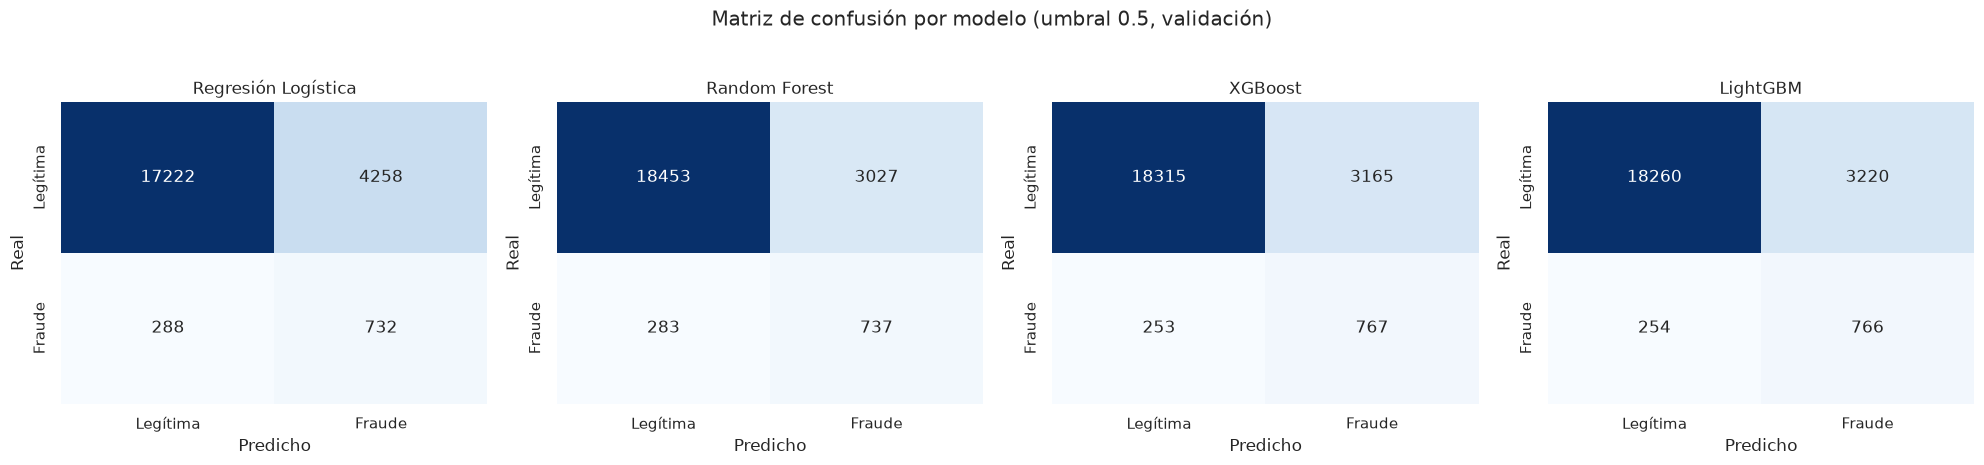

In [8]:
plot_confusion_matrices(
    val_confusion_matrices, "Matriz de confusión por modelo (umbral 0.5, validación)"
)


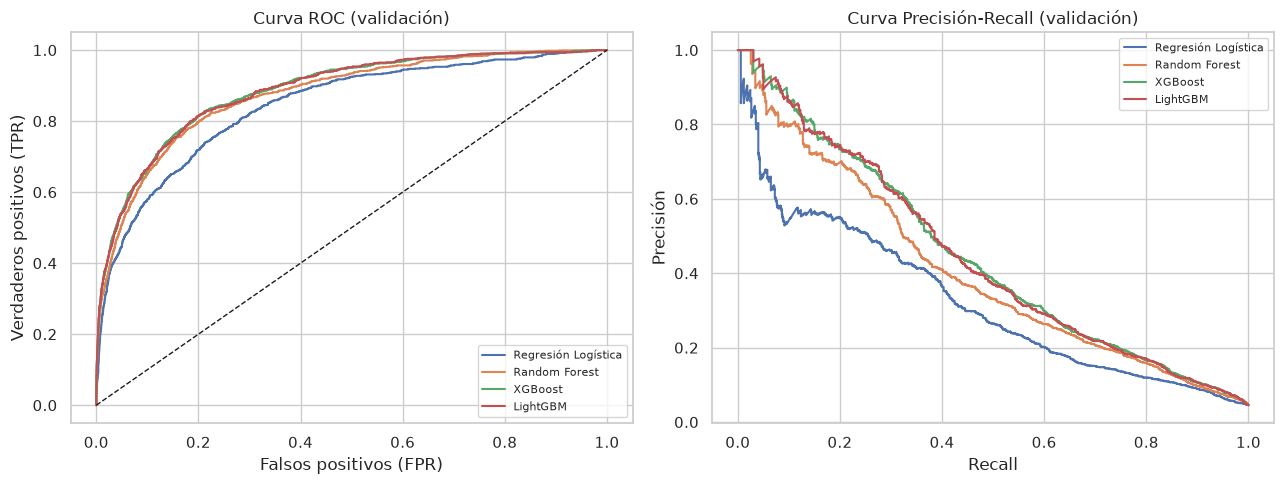

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, proba in val_proba.items():
    fpr, tpr, _ = roc_curve(y_val, proba)
    axes[0].plot(fpr, tpr, label=name)
    prec, rec, _ = precision_recall_curve(y_val, proba)
    axes[1].plot(rec, prec, label=name)

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_xlabel("Falsos positivos (FPR)")
axes[0].set_ylabel("Verdaderos positivos (TPR)")
axes[0].set_title("Curva ROC (validación)")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precisión")
axes[1].set_title("Curva Precisión-Recall (validación)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


`F6` (que pondera el recall seis veces más que la precisión) se agrega junto a F1 porque, en
fraude, un falso negativo (fraude no detectado) suele ser mucho más costoso que un falso
positivo (rechazar una transacción legítima) — algo que la propia ecuación de beneficio
también refleja (perder el 100% del monto vs. dejar de ganar el 25%). Aun así, estas métricas
usan el umbral por defecto (0.5) o son agnósticas al umbral (ROC-AUC, PR-AUC); ninguna captura
directamente la ganancia en dinero, que es el objetivo real del negocio y se aborda en la
sección siguiente.

## 6. Optimización del umbral de decisión por beneficio

Se aprueba una transacción si `P(fraude) < umbral`. Para cada modelo, se recorre un rango de
umbrales sobre **validación** y se calcula el beneficio total del portafolio con
`portfolio_profit`, usando el monto real de cada transacción. Se compara contra dos
baselines triviales: aprobar todo y rechazar todo.

In [10]:
thresholds = np.linspace(0, 1, 201)

profit_curves = {
    name: np.array([
        portfolio_profit(y_val, proba < t, monto_val) for t in thresholds
    ])
    for name, proba in val_proba.items()
}

baseline_aprobar_todo = portfolio_profit(y_val, np.ones(len(y_val), dtype=bool), monto_val)
baseline_rechazar_todo = portfolio_profit(y_val, np.zeros(len(y_val), dtype=bool), monto_val)

print(f"Baseline 'aprobar todo'  (val): $ {baseline_aprobar_todo:,.2f}")
print(f"Baseline 'rechazar todo' (val): $ {baseline_rechazar_todo:,.2f}")


Baseline 'aprobar todo'  (val): $ 138,619.50
Baseline 'rechazar todo' (val): $ 0.00


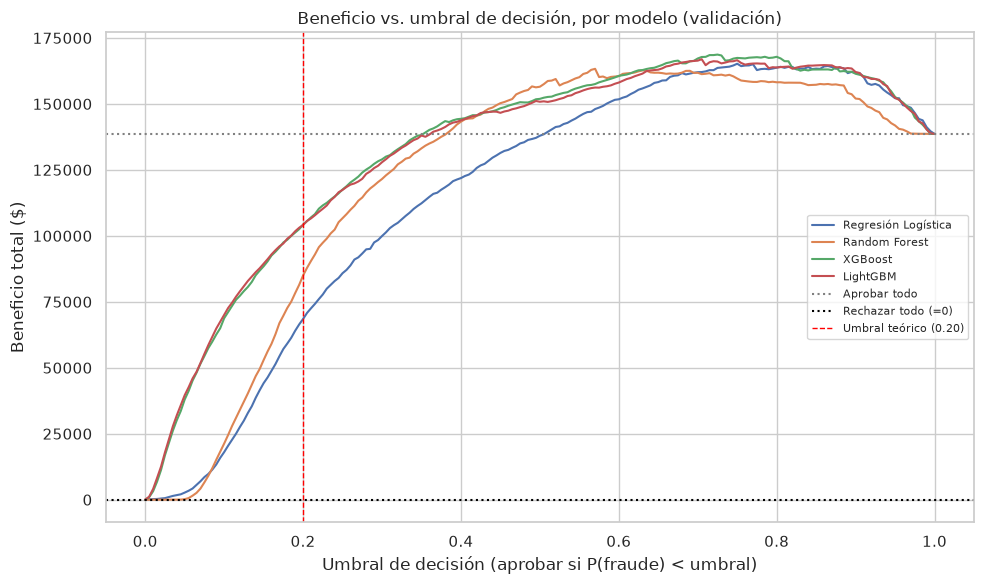

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
for name, curve in profit_curves.items():
    ax.plot(thresholds, curve, label=name)

ax.axhline(baseline_aprobar_todo, color="gray", linestyle=":", label="Aprobar todo")
ax.axhline(baseline_rechazar_todo, color="black", linestyle=":", label="Rechazar todo (=0)")
ax.axvline(OPTIMAL_THRESHOLD_TEORICO, color="red", linestyle="--", linewidth=1,
           label=f"Umbral teórico ({OPTIMAL_THRESHOLD_TEORICO:.2f})")
ax.set_xlabel("Umbral de decisión (aprobar si P(fraude) < umbral)")
ax.set_ylabel("Beneficio total ($)")
ax.set_title("Beneficio vs. umbral de decisión, por modelo (validación)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [12]:
summary_rows = []
for name, curve in profit_curves.items():
    best_idx = curve.argmax()
    summary_rows.append({
        "modelo": name,
        "umbral_optimo": thresholds[best_idx],
        "beneficio_val": curve[best_idx],
        "mejora_vs_aprobar_todo": curve[best_idx] - baseline_aprobar_todo,
    })

threshold_summary = pd.DataFrame(summary_rows).set_index("modelo").sort_values(
    "beneficio_val", ascending=False
).round(2)
threshold_summary


,umbral_optimo,beneficio_val,mejora_vs_aprobar_todo
modelo,,,
XGBoost,0.72,168693.85,30074.35
LightGBM,0.70,166946.53,28327.03
Regresión Logística,0.75,165227.75,26608.25
Random Forest,0.57,163304.35,24684.85


Todos los modelos superan ampliamente a los dos baselines triviales. El umbral óptimo
*empírico* de los cuatro modelos (0.57-0.75) queda **bastante por encima** del umbral
teórico (0.20) — y de forma consistente entre modelos, no es un caso aislado. La causa más
probable es el manejo del desbalance: `class_weight="balanced"` y `scale_pos_weight`
entrenan al modelo *como si* el fraude fuera ~18 veces más frecuente de lo que realmente es,
lo que **infla sistemáticamente** las probabilidades de fraude que predice. El umbral teórico
de 0.20 solo es válido si `P(fraude)` está bien calibrada en la escala real (5% de tasa
base); con probabilidades infladas por el reponderado de clases, el punto de corte que
maximiza el beneficio se desplaza hacia arriba, aunque la lógica de negocio no haya cambiado.
Por eso el umbral se optimiza empíricamente sobre validación en vez de aplicar 0.20
directamente — y por eso, si en el futuro se recalibran las probabilidades (por ejemplo con
`CalibratedClassifierCV`), habría que volver a barrer el umbral.

## 7. Selección del modelo final

In [13]:
best_model_name = threshold_summary["beneficio_val"].idxmax()
best_threshold = threshold_summary.loc[best_model_name, "umbral_optimo"]
best_model = models[best_model_name]

print(f"Modelo final: {best_model_name}")
print(f"Umbral de decisión elegido (fijado en validación): {best_threshold:.3f}")


Modelo final: XGBoost
Umbral de decisión elegido (fijado en validación): 0.720


El umbral se elige y se congela usando **solo validación**; en la Sección 8 se evalúa una
única vez sobre test con este umbral ya fijo, sin volver a optimizarlo — igual que se haría
en producción, donde el umbral de negocio se calibra antes de desplegar y no se ajusta mirando
los resultados que se están intentando predecir.

In [14]:
best_model_metrics = []
best_model_cms = {}
for split_name, X_split, y_split in [
    ("train", X_train, y_train),
    ("val", X_val, y_val),
    ("test", X_test, y_test),
]:
    proba_split = best_model.predict_proba(X_split)[:, 1]
    y_pred_split = (proba_split >= best_threshold).astype(int)
    best_model_cms[split_name] = confusion_matrix(y_split, y_pred_split)
    best_model_metrics.append({
        "split": split_name,
        "ROC-AUC": roc_auc_score(y_split, proba_split),
        "PR-AUC": average_precision_score(y_split, proba_split),
        "Precision": precision_score(y_split, y_pred_split),
        "Recall": recall_score(y_split, y_pred_split),
        "F1": fbeta_score(y_split, y_pred_split, beta=1),
        "F6": fbeta_score(y_split, y_pred_split, beta=6),
    })

best_model_metrics_df = pd.DataFrame(best_model_metrics).set_index("split").round(4)
best_model_metrics_df


,ROC-AUC,PR-AUC,Precision,Recall,F1,F6
split,,,,,,
train,0.9286,0.5421,0.3778,0.6684,0.4828,0.6548
val,0.8855,0.4419,0.3190,0.5657,0.4079,0.5541
test,0.8857,0.4310,0.3203,0.5685,0.4097,0.5569


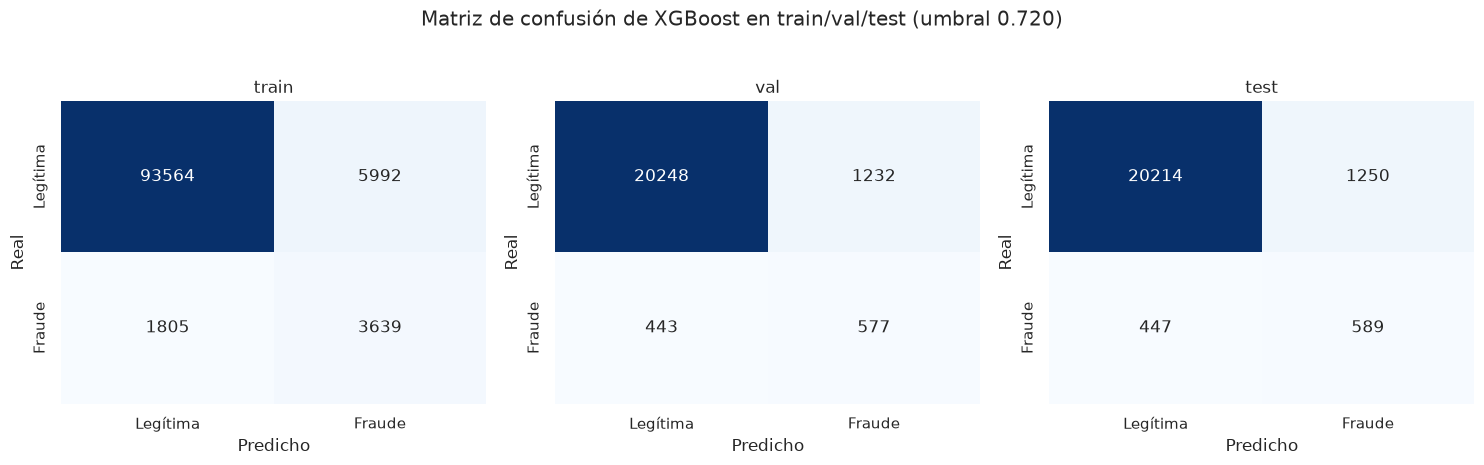

In [15]:
plot_confusion_matrices(
    best_model_cms,
    f"Matriz de confusión de {best_model_name} en train/val/test (umbral {best_threshold:.3f})",
)


### ¿Por qué XGBoost es el mejor modelo?

Tres líneas de evidencia independientes, todas a favor del mismo modelo:

1. **Mejor discriminación en validación (Sección 5).** Entre los 4 candidatos, XGBoost
   tiene el ROC-AUC más alto (0.8855) y el PR-AUC más alto (0.4419) — esta última es la
   métrica más informativa dado el desbalance de clases (5% fraude). También empata en
   punta con LightGBM en F6 (0.6981 vs. 0.6963), la métrica que más pesa el recall.

2. **Mayor beneficio en dólares en validación (Sección 6).** Este es el criterio que
   realmente importa para el negocio: con su propio umbral óptimo, XGBoost genera
   **$168,693.85**, por encima de LightGBM ($166,946.53), Regresión Logística
   ($165,227.75) y Random Forest ($163,304.35). Ningún otro modelo lo supera bajo
   ningún umbral.

3. **Generalización estable entre train, val y test (esta sección).**

   | Split | ROC-AUC | PR-AUC | Precision | Recall | F1 | F6 |
   |---|---|---|---|---|---|---|
   | train | 0.9286 | 0.5421 | 0.3778 | 0.6684 | 0.4828 | 0.6548 |
   | val | 0.8855 | 0.4419 | 0.3190 | 0.5657 | 0.4079 | 0.5541 |
   | test | 0.8857 | 0.4310 | 0.3203 | 0.5685 | 0.4097 | 0.5569 |

   Hay una brecha moderada entre train y val/test (ROC-AUC 0.93 vs. ~0.885) — esperable en
   un ensemble de 300 árboles y no alarmante, pero muestra que el modelo memoriza algo de
   señal específica de entrenamiento. Lo importante es que **val y test son casi idénticos**
   en las seis métricas (diferencias en el tercer decimal), a pesar de que test es un
   período de fechas que el modelo nunca usó ni para entrenar ni para elegir el umbral. Eso
   es la mejor evidencia posible de que la elección de modelo y umbral no fue un
   sobreajuste a la partición de validación, y de que el desempeño debería sostenerse en
   producción en el corto plazo.

En conjunto: mejor ranking de riesgo, mayor beneficio económico, y desempeño que se
mantiene estable frente a datos que el modelo nunca vio — las tres condiciones que
justifican elegir XGBoost sobre los otros tres candidatos.

## 8. Evaluación final en test

In [16]:
test_proba = best_model.predict_proba(X_test)[:, 1]
test_approved = test_proba < best_threshold

profit_test_model = portfolio_profit(y_test, test_approved, monto_test)
profit_test_aprobar_todo = portfolio_profit(y_test, np.ones(len(y_test), dtype=bool), monto_test)
profit_test_rechazar_todo = portfolio_profit(y_test, np.zeros(len(y_test), dtype=bool), monto_test)

print(f"Beneficio en test — {best_model_name} (umbral {best_threshold:.3f}): $ {profit_test_model:,.2f}")
print(f"Beneficio en test — Aprobar todo:                     $ {profit_test_aprobar_todo:,.2f}")
print(f"Beneficio en test — Rechazar todo:                    $ {profit_test_rechazar_todo:,.2f}")
print(f"Mejora vs. aprobar todo: $ {profit_test_model - profit_test_aprobar_todo:,.2f}")


Beneficio en test — XGBoost (umbral 0.720): $ 173,689.23
Beneficio en test — Aprobar todo:                     $ 138,456.16
Beneficio en test — Rechazar todo:                    $ 0.00
Mejora vs. aprobar todo: $ 35,233.06


In [17]:
test_pred_05 = (test_proba >= 0.5).astype(int)
test_pred_business = (~test_approved).astype(int)  # 1 = se predice/decide que es fraude (se rechaza)

final_metrics = pd.DataFrame({
    "ROC-AUC": [roc_auc_score(y_test, test_proba)],
    "PR-AUC": [average_precision_score(y_test, test_proba)],
    "Precision @0.5": [precision_score(y_test, test_pred_05)],
    "Recall @0.5": [recall_score(y_test, test_pred_05)],
    "F1 @0.5": [fbeta_score(y_test, test_pred_05, beta=1)],
    "F6 @0.5": [fbeta_score(y_test, test_pred_05, beta=6)],
    "Precision @umbral_negocio": [precision_score(y_test, test_pred_business)],
    "Recall @umbral_negocio": [recall_score(y_test, test_pred_business)],
    "F1 @umbral_negocio": [fbeta_score(y_test, test_pred_business, beta=1)],
    "F6 @umbral_negocio": [fbeta_score(y_test, test_pred_business, beta=6)],
}, index=[best_model_name]).round(4)
final_metrics


,ROC-AUC,PR-AUC,Precision @0.5,Recall @0.5,F1 @0.5,F6 @0.5,Precision @umbral_negocio,Recall @umbral_negocio,F1 @umbral_negocio,F6 @umbral_negocio
XGBoost,0.8857,0.431,0.1997,0.749,0.3153,0.6972,0.3203,0.5685,0.4097,0.5569


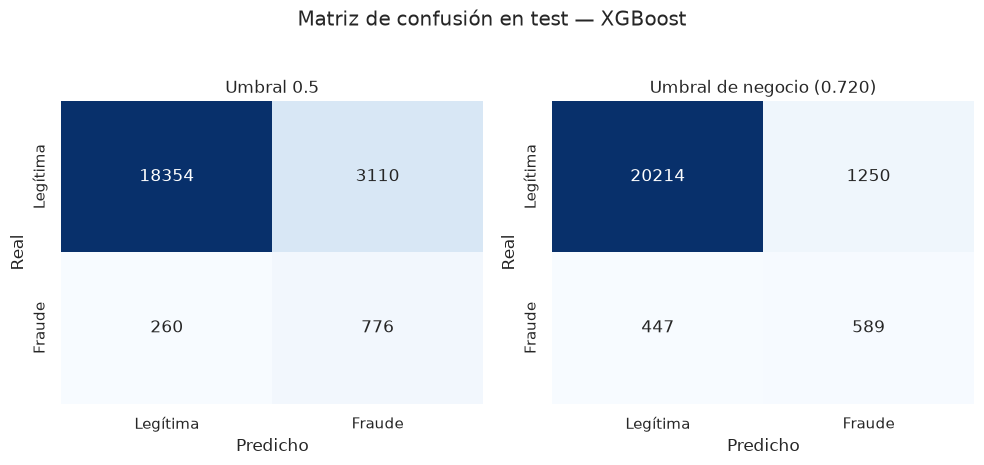

In [18]:
test_confusion_matrices = {
    "Umbral 0.5": confusion_matrix(y_test, test_pred_05),
    f"Umbral de negocio ({best_threshold:.3f})": confusion_matrix(y_test, test_pred_business),
}
plot_confusion_matrices(
    test_confusion_matrices, f"Matriz de confusión en test — {best_model_name}"
)


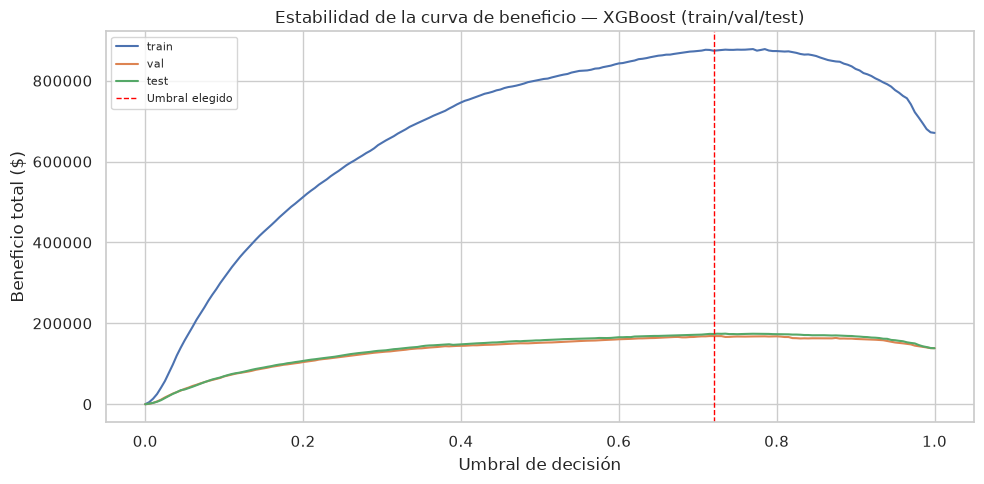

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
for name_split, y_split, monto_split, proba_split in [
    ("train", y_train, monto_train, best_model.predict_proba(X_train)[:, 1]),
    ("val", y_val, monto_val, val_proba[best_model_name]),
    ("test", y_test, monto_test, test_proba),
]:
    curve = np.array([portfolio_profit(y_split, proba_split < t, monto_split) for t in thresholds])
    ax.plot(thresholds, curve, label=name_split)

ax.axvline(best_threshold, color="red", linestyle="--", linewidth=1, label="Umbral elegido")
ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("Beneficio total ($)")
ax.set_title(f"Estabilidad de la curva de beneficio — {best_model_name} (train/val/test)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


Si la forma de la curva y la ubicación de su máximo son similares entre train, val y test,
es una buena señal de que el umbral elegido no es un artefacto de una partición en particular
y debería seguir siendo razonable en producción, al menos en el corto plazo (sujeto al
monitoreo de *drift* que se discute en el informe final).

## 9. Interpretabilidad (importancia de variables)

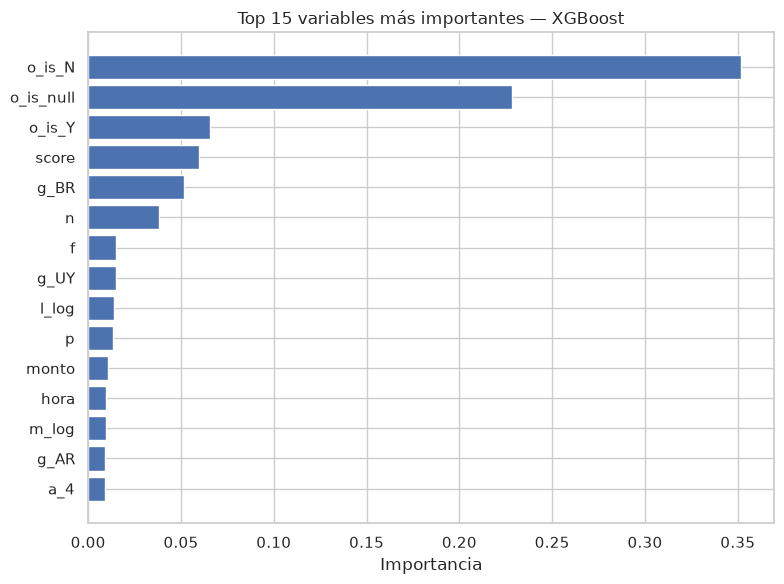

In [20]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols)
elif hasattr(best_model, "named_steps"):
    coefs = best_model.named_steps["clf"].coef_[0]
    importances = pd.Series(np.abs(coefs), index=feature_cols)
else:
    importances = pd.Series(dtype=float)

importances = importances.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importances.index, importances.values, color="#4C72B0")
ax.set_title(f"Top 15 variables más importantes — {best_model_name}")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()


Las variables más relevantes para el modelo ganador deberían ser, en general, consistentes
con las que ya se identificaron como más informativas en el EDA (`score`, `j_freq`, los
flags de `o`, `monto`) — si aparece con mucho peso una variable inesperada, vale la pena
revisar si hay algún problema de leakage antes de confiar en el resultado.

## 10. Guardado del modelo final

In [21]:
import os

os.makedirs(ARTIFACTS_DIR, exist_ok=True)

joblib.dump(
    {
        "model_name": best_model_name,
        "model": best_model,
        "threshold": float(best_threshold),
        "feature_columns": feature_cols,
    },
    f"{ARTIFACTS_DIR}/final_model.pkl",
)
print(f"Guardado {ARTIFACTS_DIR}/final_model.pkl")


Guardado ../artifacts/final_model.pkl


El artefacto guardado incluye el modelo entrenado, el umbral de negocio congelado y la lista
exacta de columnas esperadas — todo lo necesario para reproducir la decisión de
aprobar/rechazar sobre una transacción nueva sin tener que recalcular nada a partir de este
notebook.

## 11. Conclusión y próximos pasos

- Se entrenaron cuatro modelos (Regresión Logística, Random Forest, XGBoost, LightGBM) sobre
  el dataset con 37 features de `2_feature_engineering.ipynb`, manejando el desbalance de
  clases con pesos de clase en vez de resampling.
- **XGBoost fue elegido con tres líneas de evidencia independientes, no solo por una
  métrica aislada** (detalle completo en la Sección 7):
  1. Mejor ROC-AUC (0.8855) y PR-AUC (0.4419) entre los 4 candidatos en validación.
  2. Mayor beneficio en validación ($168,693.85) bajo su propio umbral óptimo, por encima
     de LightGBM, Regresión Logística y Random Forest.
  3. Generalización estable: hay una brecha esperable entre train (ROC-AUC 0.93) y val/test
     (~0.885), pero val y test son casi idénticos entre sí en las seis métricas — buena
     señal de que el modelo y el umbral no están sobreajustados a la partición de
     validación.
- Todos los modelos, evaluados con su umbral óptimo de negocio, superan ampliamente a los
  baselines triviales de "aprobar todo" y "rechazar todo" en beneficio total.
- El umbral de decisión se optimizó **en validación** maximizando directamente el beneficio
  (no accuracy ni F1), y se validó una única vez en test sin volver a ajustarlo — replicando
  cómo se calibraría antes de un despliegue real.
- El umbral óptimo empírico de cada modelo se comparó contra el umbral teórico (0.20)
  derivado en `0_getting_started.ipynb`, como forma de detectar problemas de calibración.
